# 2. Tournaments: who does best against everybody?

**Goal.** 
- Organise a round-robin tournament "à la Axelrod", 
- read its results and plots, 
- and see how the ranking depends on the **population** of opponents, on the **payoff matrix** and on **errors** (noise).

In [ ]:
#if axelrod is not installed on colab, install it with
#!pip install axelrod

In [ ]:
# !!!! ONLY ON COLAB !!!!
import sys
import os
from google.colab import drive

#give access to your personal Google Drive (check the authorization, ...)
drive.mount('/content/drive')

# 2. Add the exact path where you put the jupyter books and myIGTools.py
# (Example : if it is in folder the "Colab Notebooks/Axelrod-Book" on your Drive)
my_folder = '/content/drive/MyDrive/Colab Notebooks/Axelrod-Book'  # Change this to the path where you put the jupyter books and myIGTools.py
if my_folder not in sys.path: 
    sys.path.insert(0, my_folder)
if os.path.exists(my_folder):
    print(f"OK! the folder exists ! So you can use the jupyter books and myIGTools.py in this folder.")
    fichiers = os.listdir(my_folder)
    print("Content of the folder :", fichiers)    
    # Force insertion of the folder at the beginning of the path
    if my_folder not in sys.path:
        sys.path.insert(0, my_folder)        
else:
    print(f"ERROR: folder does not exist at this path. Verify the spelling or the space.")


In [1]:
import axelrod as axl
import numpy as np
import matplotlib.pyplot as plt
from myIGTools import show_game, print_ranking, mean_scores

pd = axl.Game()                                  # prisoner's dilemma (R=3, S=0, T=5, P=1)
stag = axl.Game(r=4, s=0, t=3, p=3)              # stag hunt
chicken = axl.Game(r=3, s=1, t=5, p=0)           # chicken

## 2.1 A round-robin tournament

In 1980, Robert Axelrod asked researchers to submit strategies for the repeated prisoner's dilemma.  
Each strategy met every other one (and a copy of itself) for 200 turns; strategies were ranked by their **total score**, not by the number of matches won.

`axl.Tournament` does the same. Because some strategies are random, each match is repeated (`repetitions`).  
The score used below is the **mean score per turn**.

A tournament "uses up" its players: we create a fresh list each time with a small function.

In [3]:
def make_players():
    return [axl.Cooperator(), axl.Defector(), axl.TitForTat(), axl.Grudger(),
            axl.WinStayLoseShift(), axl.Alternator(), axl.Random()]
#set up the tournament on pd (prisoner dilemma) with 100 turns and 5 repetitions, and a random seed of 1
tournament = axl.Tournament(make_players(), turns=100, repetitions=5, game=pd, seed=1)
#lets play the tournament and print the results
results = tournament.play(progress_bar=False)
print("Results of the tournament on Prisoner's dilemma!")
print("5 x 100 turns, mean scores of the players:")
print_ranking(results, "Prisoner's dilemma")

Results of the tournament on Prisoner's dilemma!
5 x 100 turns, mean scores of the players:
Prisoner's dilemma
  1. Defector                                    2.70
  2. Grudger                                     2.66
  3. Tit For Tat                                 2.44
  4. Win-Stay Lose-Shift                         2.35
  5. Alternator                                  2.01
  6. Cooperator                                  2.00
  7. Random: 0.5                                 1.96



`axl.Plot(results)` draws the classic tournament plots in one line each. 
- The **boxplot** shows the spread of each strategy's score over the repetitions; 
- the **payoff matrix** shows the mean score per turn of the row strategy against the column strategy.

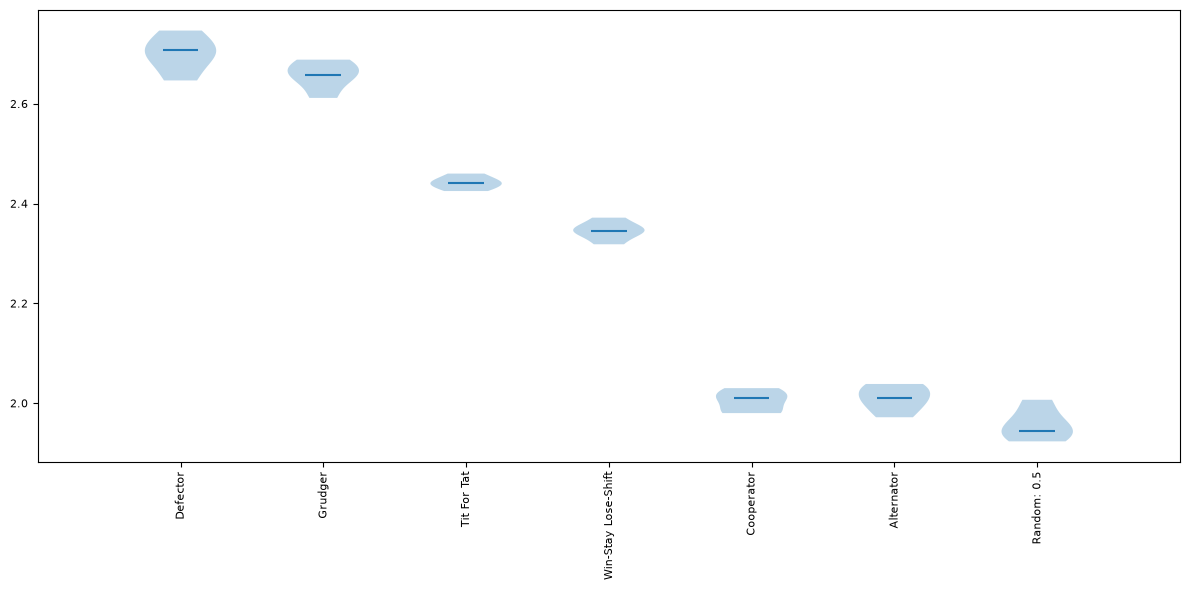

In [4]:
plot = axl.Plot(results)
plot.boxplot()
plt.show()

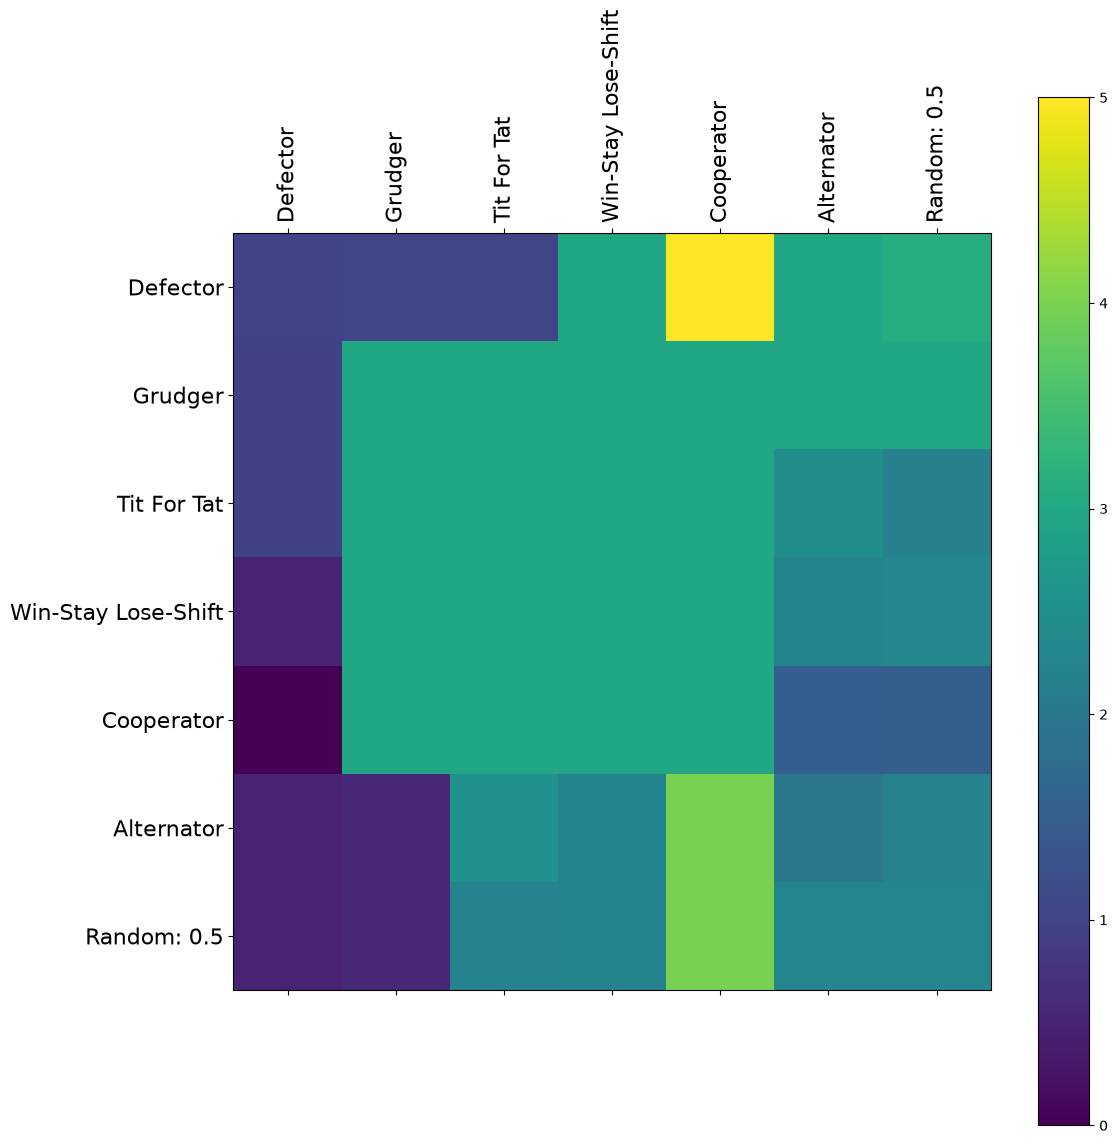

In [5]:
plot.payoff()
plt.show()

**Reading.**   
Surprise: **Defector wins**!   
The heatmap explains why: it collects $T=5$ per turn against Cooperator, and a lot against Alternator and Random.   
Against the reactive strategies (Tit For Tat, Grudger), it only gets about $P=1$, while those strategies earn $R=3$ per turn among themselves.

The ranking of a tournament depends on **who else is playing**.

----

**Question 1** *(≈ 4 lines)*. 
- Run the same tournament **without** the three "naive" strategies (Cooperator, Alternator, Random). 
- Print the ranking. Who wins now?

In [5]:
# Exercise 1: your code here

Without naive strategies
  1. Tit For Tat                                 2.33
  2. Grudger                                     2.33
  3. Win-Stay Lose-Shift                         2.17
  4. Defector                                    1.69



Without victims to exploit, Defector falls to the last place: Tit For Tat and Grudger share the first place. They are **nice** (never the first to defect) and **retaliating** (they punish a defection), the two properties Axelrod highlighted.


---

**Question 2** *(≈ 5 lines)*. 
- `axl.axelrod_first_strategies` is the list of the strategies (classes) of Axelrod's **first tournament** (1980). 
- Run it with `turns=200, repetitions=3, seed=1`, print the ranking and draw the boxplot. Where is Tit For Tat?

*Hint:* `[s() for s in axl.axelrod_first_strategies]` builds the players.

In [ ]:
# Question 2: your code here

Axelrod's first tournament (reproduction)
  1. First by Stein and Rapoport: 0.05: (D, D)   2.60
  2. First by Grofman                            2.54
  3. First by Shubik                             2.50
  4. Tit For Tat                                 2.49
  5. First by Tideman and Chieruzzi: (D, D)      2.47
  6. First by Nydegger                           2.46
  7. First by Davis: 10                          2.40
  8. Grudger                                     2.39
  9. First by Graaskamp: 0.05                    2.27
 10. First by Downing                            2.25
 11. First by Feld: 1.0, 0.5, 200                1.90
 12. First by Joss: 0.9                          1.75
 13. First by Tullock                            1.74
 14. Random: 0.5                                 1.61
 15. First by Anonymous                          1.61



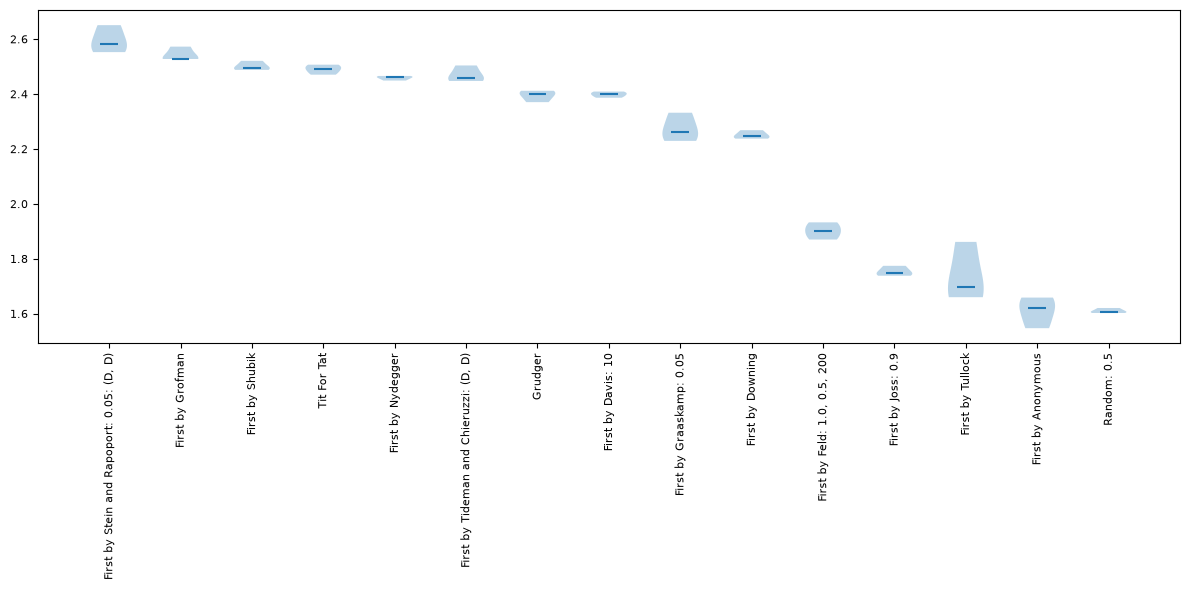

Tit For Tat won the original tournament.  
In this reproduction it is in the leading group, close to the winners: several original strategies are random or were rebuilt from their descriptions, so the exact order varies, but the **nice and retaliating** strategies occupy the top of the ranking, and the "nasty" ones (Joss, Tullock, Anonymous) are at the bottom.

---

## 2.2 Changing the matrix

**Question 3** *(≈ 5 lines)*. 
- Run the tournament of section 2.1 (`make_players()`) with the **stag hunt** and with **chicken** (parameter `game=`), 
- and print both rankings. What happens to Defector?

In [9]:
# Exercise 3: your code here

Stag hunt
       C         D     
C    (4, 4)    (0, 3)  
D    (3, 0)    (3, 3)  

  1. Grudger                                     3.49
  2. Tit For Tat                                 3.18
  3. Win-Stay Lose-Shift                         3.09
  4. Defector                                    3.00
  5. Cooperator                                  2.67
  6. Random: 0.5                                 2.34
  7. Alternator                                  2.17

Chicken
       C         D     
C    (3, 3)    (1, 5)  
D    (5, 1)    (0, 0)  

  1. Tit For Tat                                 2.35
  2. Win-Stay Lose-Shift                         2.35
  3. Cooperator                                  2.34
  4. Grudger                                     2.33
  5. Defector                                    2.12
  6. Alternator                                  2.09
  7. Random: 0.5                                 1.96



- **Stag hunt**: mutual cooperation is the best outcome ($R > T$), so the strategies that cooperate with each other (Grudger, Tit For Tat) win. Defector gets a safe $3$ per turn, but no more.
- **Chicken**: mutual defection is the worst outcome ($P=0$): Defector drops to 5th place, and Cooperator, which never collides, is close to the top.

Same strategies, same moves, different numbers in the matrix: different winners.

---

## 2.3 Errors: the noisy tournament

In real interactions, moves can be misread or mis-executed.  
With `noise=0.05`, each move is flipped with probability 5 %. Between two Tit For Tat, a single error starts an endless echo of retaliations.

In [5]:
m = axl.Match((axl.TitForTat(), axl.TitForTat()), turns=30, noise=0.05, seed=4)
m.play()
print(m.sparklines(c_symbol="C", d_symbol="D"))
print(m.sparklines(c_symbol="🤝", d_symbol="🐍"))


CCCCDCDCCDCDCDCDCDCDCDCDCDCDCD
CCCDCDCDCCDCDCDCDCDCDCDCDCDCDC
🤝🤝🤝🤝🐍🤝🐍🤝🤝🐍🤝🐍🤝🐍🤝🐍🤝🐍🤝🐍🤝🐍🤝🐍🤝🐍🤝🐍🤝🐍
🤝🤝🤝🐍🤝🐍🤝🐍🤝🤝🐍🤝🐍🤝🐍🤝🐍🤝🐍🤝🐍🤝🐍🤝🐍🤝🐍🤝🐍🤝


----

**Question 4** *(≈ 10 lines, with a plot)*. 
- Add the two "forgiving" strategies `axl.TitFor2Tats()` and `axl.GTFT()` (generous Tit For Tat) to `make_players()`. 
- For each noise level in `[0, 0.02, 0.05, 0.1, 0.2]`, run the tournament (`game=pd`) and record `mean_scores(results)` (a dictionary `{name: score}`). 
- Then draw one curve per strategy: score as a function of noise. Which strategies suffer from noise? Which ones benefit from it?

In [12]:
# Exercise 4: your code here

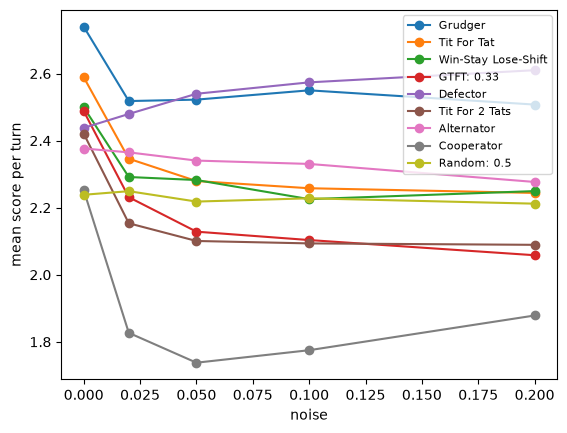

Noise breaks cooperation between the nice strategies (Cooperator, Tit For Tat, Tit For 2 Tats, GTFT…), so their scores drop.  
Defector is barely affected: it never relied on cooperation, and it now exploits everybody's mistakes.  
With these opponents, being forgiving does not pay: the forgiving strategies also forgive Defector and Random.

----

## Summary

| To… | write |
|---|---|
| run a tournament | `axl.Tournament(players, turns=…, repetitions=…, game=…, noise=…, seed=…).play(progress_bar=False)` |
| get the ranking | `results.ranked_names`, or `print_ranking(results)` |
| get the mean score per turn | `mean_scores(results)` (from `results.normalised_scores`) |
| plot | `axl.Plot(results).boxplot()`, `.payoff()`, `.winplot()` |
| Axelrod's 1980 strategies | `axl.axelrod_first_strategies` |